In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp   

Yearly average TB1 (EUR/MWh):
Year
2022    126.42
2023     62.42
2024     61.60
2025     79.38
2026     52.91
Name: TB1, dtype: float64


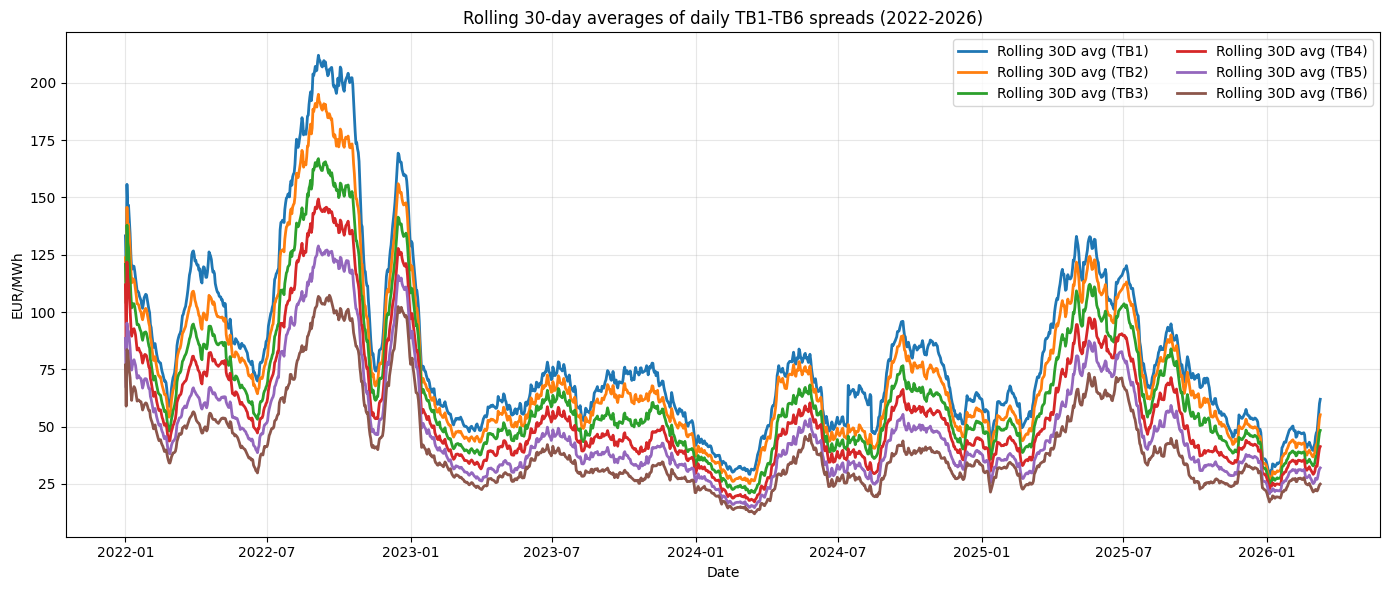

In [47]:
from pathlib import Path
# --- load all spot-market CSV files (supports both wide and long formats) ---
data_dir = Path("auction_spot_prices")
csv_files = sorted(data_dir.glob("auction_spot_prices_switzerland_*.csv"))
if not csv_files:
    raise FileNotFoundError("No matching auction_spot_prices_switzerland_*.csv files found.")

# --- plot switches ---
INCLUDE_DAILY_TB = False   # True: plot daily TB lines + rolling averages; False: rolling averages only

def tb_spreads(values):
    vals = np.sort(values[~np.isnan(values)])
    out = []
    for k in range(1, 7):
        if len(vals) >= 2 * k:
            out.append(vals[-k] - vals[k - 1])
        else:
            out.append(np.nan)
    return out
tb_frames = []
for f in csv_files:
    d = pd.read_csv(f, comment="#")
    # Format A (2023+): one row per day with Hour columns
    if "Delivery day" in d.columns:
        d["Delivery day"] = pd.to_datetime(d["Delivery day"], dayfirst=True, errors="coerce")
        hour_cols = [c for c in d.columns if c.startswith("Hour")]
        d[hour_cols] = d[hour_cols].apply(pd.to_numeric, errors="coerce")
        tb_vals = d[hour_cols].apply(lambda r: tb_spreads(r.to_numpy(dtype=float)), axis=1, result_type="expand")
        tb_vals.columns = ["TB1", "TB2", "TB3", "TB4", "TB5", "TB6"]
        t = pd.concat([d[["Delivery day"]], tb_vals], axis=1)
        t = t.dropna(subset=["Delivery day"])
        tb_frames.append(t)
    # Format B (2022): one row per hour with MTU + Price
    elif "MTU (CET/CEST)" in d.columns and "Price" in d.columns:
        d["Price"] = pd.to_numeric(d["Price"], errors="coerce")
        # Extract start date from strings like '01/01/2022 00:00 - 01/01/2022 01:00'
        d["Delivery day"] = pd.to_datetime(
            d["MTU (CET/CEST)"].astype(str).str.extract(r"(\d{2}/\d{2}/\d{4})")[0],
            dayfirst=True,
            errors="coerce",
        )
        d2 = d.dropna(subset=["Delivery day", "Price"]).copy()
        g = d2.groupby("Delivery day")["Price"].apply(
            lambda s: pd.Series(tb_spreads(s.to_numpy(dtype=float)), index=["TB1", "TB2", "TB3", "TB4", "TB5", "TB6"])
        )
        t = g.unstack().reset_index()
        tb_frames.append(t)
if not tb_frames:
    raise ValueError("No supported CSV format found in the selected files.")
df = pd.concat(tb_frames, ignore_index=True)
df = df.dropna(subset=["Delivery day"]).sort_values("Delivery day")

# If overlapping dates exist across files, keep one row per day
df = df.groupby("Delivery day", as_index=False)[["TB1", "TB2", "TB3", "TB4", "TB5", "TB6"]].mean()
yearly_average_tb1 = df.assign(Year=df["Delivery day"].dt.year).groupby("Year")["TB1"].mean()
print("Yearly average TB1 (EUR/MWh):")
print(yearly_average_tb1.round(2))
# --- rolling 30-day averages ---
tb_cols = ["TB1", "TB2", "TB3", "TB4", "TB5", "TB6"]
for col in tb_cols:
    df[f"{col}_rolling_30d"] = df[col].rolling(window=30, min_periods=1).mean()
# --- plot (daily TB1..TB6 + rolling 30d averages) ---
year_min = int(df["Delivery day"].dt.year.min())
year_max = int(df["Delivery day"].dt.year.max())
plt.figure(figsize=(14, 6))
if INCLUDE_DAILY_TB:
    for col in tb_cols:
        plt.plot(df["Delivery day"], df[col], label=f"Daily {col}", alpha=0.35)
for col in tb_cols:
    plt.plot(df["Delivery day"], df[f"{col}_rolling_30d"], label=f"Rolling 30D avg ({col})", linewidth=2)
plt.title(f"Rolling 30-day averages of daily TB1-TB6 spreads ({year_min}-{year_max})")
plt.xlabel("Date")
plt.ylabel("EUR/MWh")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [48]:
#battery input parameters
capacity = 0.215 #MWh
c_rate = 0.5
round_trip_efficiency = 0.90
power = capacity * c_rate
max_daily_cycles = 1

#finance parameters
specific_hardware_cost = 242 # range: 242-231
spefific_installation_cost = 141 #range: 141-106
cost = (specific_hardware_cost + spefific_installation_cost) * capacity * 1000
Interest_rate = 0.05

def calculate_daily_revenue(
    df_input,
    power,
    max_daily_cycles,
    round_trip_efficiency=1.0,
    year=None,
    average_spread=None,
):
    tb_count_used = min(int(max_daily_cycles * 2), 6)
    tb_cols_used = [f"TB{i}" for i in range(1, tb_count_used + 1)]
    revenue_df = df_input.copy()

    if year is not None:
        revenue_df = revenue_df[revenue_df["Delivery day"].dt.year == year].copy()

    scaled_tb = revenue_df[tb_cols_used].copy()
    historical_average_spread = revenue_df["TB1"].mean()

    if average_spread is not None:
        if pd.isna(historical_average_spread) or historical_average_spread == 0:
            raise ValueError("Historical average spread is zero or NaN, so scaling is not possible.")
        spread_scale_factor = average_spread / historical_average_spread
        scaled_tb = scaled_tb * spread_scale_factor

    revenue = scaled_tb.sum(axis=1) * power * round_trip_efficiency
    return pd.DataFrame({
        "Delivery day": revenue_df["Delivery day"],
        "daily_revenue_eur": revenue,
        "daily_revenue_rolling_30d": revenue.rolling(window=30, min_periods=1).mean(),
        "historical_average_spread": historical_average_spread,
        "applied_average_spread": average_spread if average_spread is not None else historical_average_spread,
    }), tb_cols_used

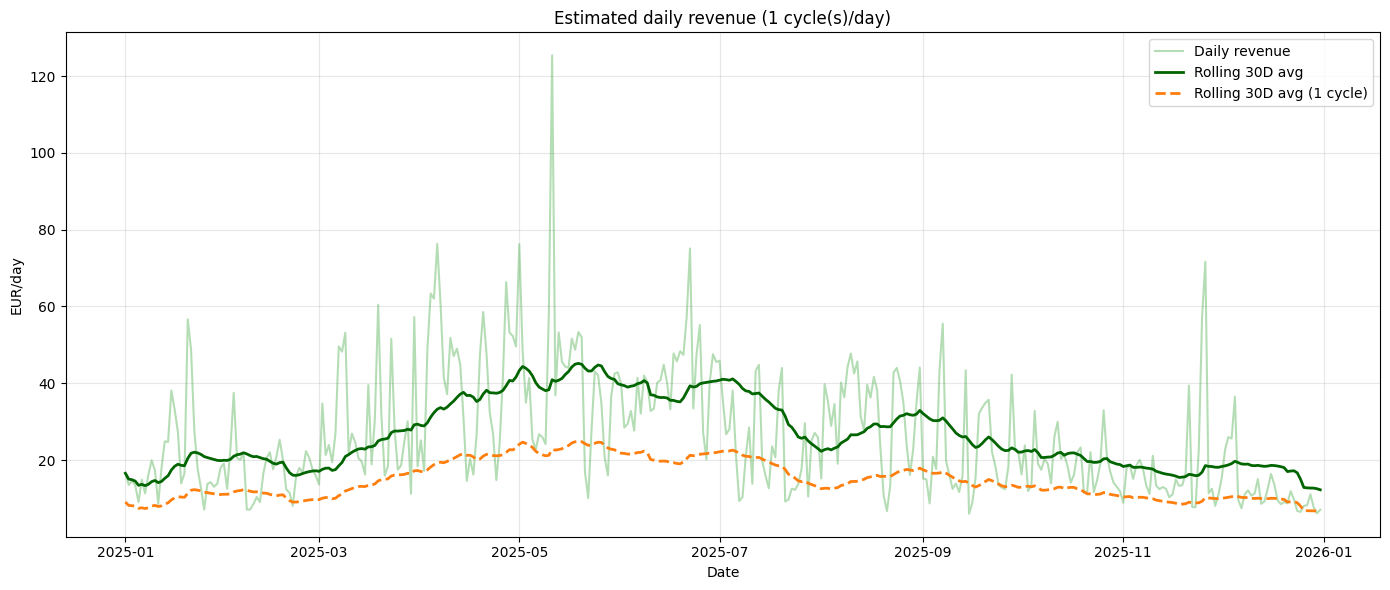

In [49]:
# --- daily revenue plot based on selected number of daily cycles ---
revenue_df, tb_cols_used = calculate_daily_revenue(
    df,
    power=power,
    max_daily_cycles=2,
    round_trip_efficiency=round_trip_efficiency, 
    year= 2025,
    average_spread=None,
)
single_cycle_revenue_df, _ = calculate_daily_revenue(
    df,
    power=power,
    max_daily_cycles=1,
    round_trip_efficiency=round_trip_efficiency,
    year= 2025,
    average_spread=None,
)
df["daily_revenue_eur"] = revenue_df["daily_revenue_eur"]
df["daily_revenue_rolling_30d"] = revenue_df["daily_revenue_rolling_30d"]
df["single_cycle_revenue_rolling_30d"] = single_cycle_revenue_df["daily_revenue_rolling_30d"]

plt.figure(figsize=(14, 6))
plt.plot(df["Delivery day"], df["daily_revenue_eur"], label="Daily revenue", color="tab:green", alpha=0.35)
plt.plot(df["Delivery day"], df["daily_revenue_rolling_30d"], label="Rolling 30D avg", color="darkgreen", linewidth=2)
plt.plot(df["Delivery day"], df["single_cycle_revenue_rolling_30d"], label="Rolling 30D avg (1 cycle)", color="tab:orange", linewidth=2, linestyle="--")
plt.title(f"Estimated daily revenue ({max_daily_cycles} cycle(s)/day)")
plt.xlabel("Date")
plt.ylabel("EUR/day")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Projection year repeated: 2025
Annual revenue used: 9,629.88 EUR/year
Investment cost: 82,345.00 EUR
Discount rate: 5.00%


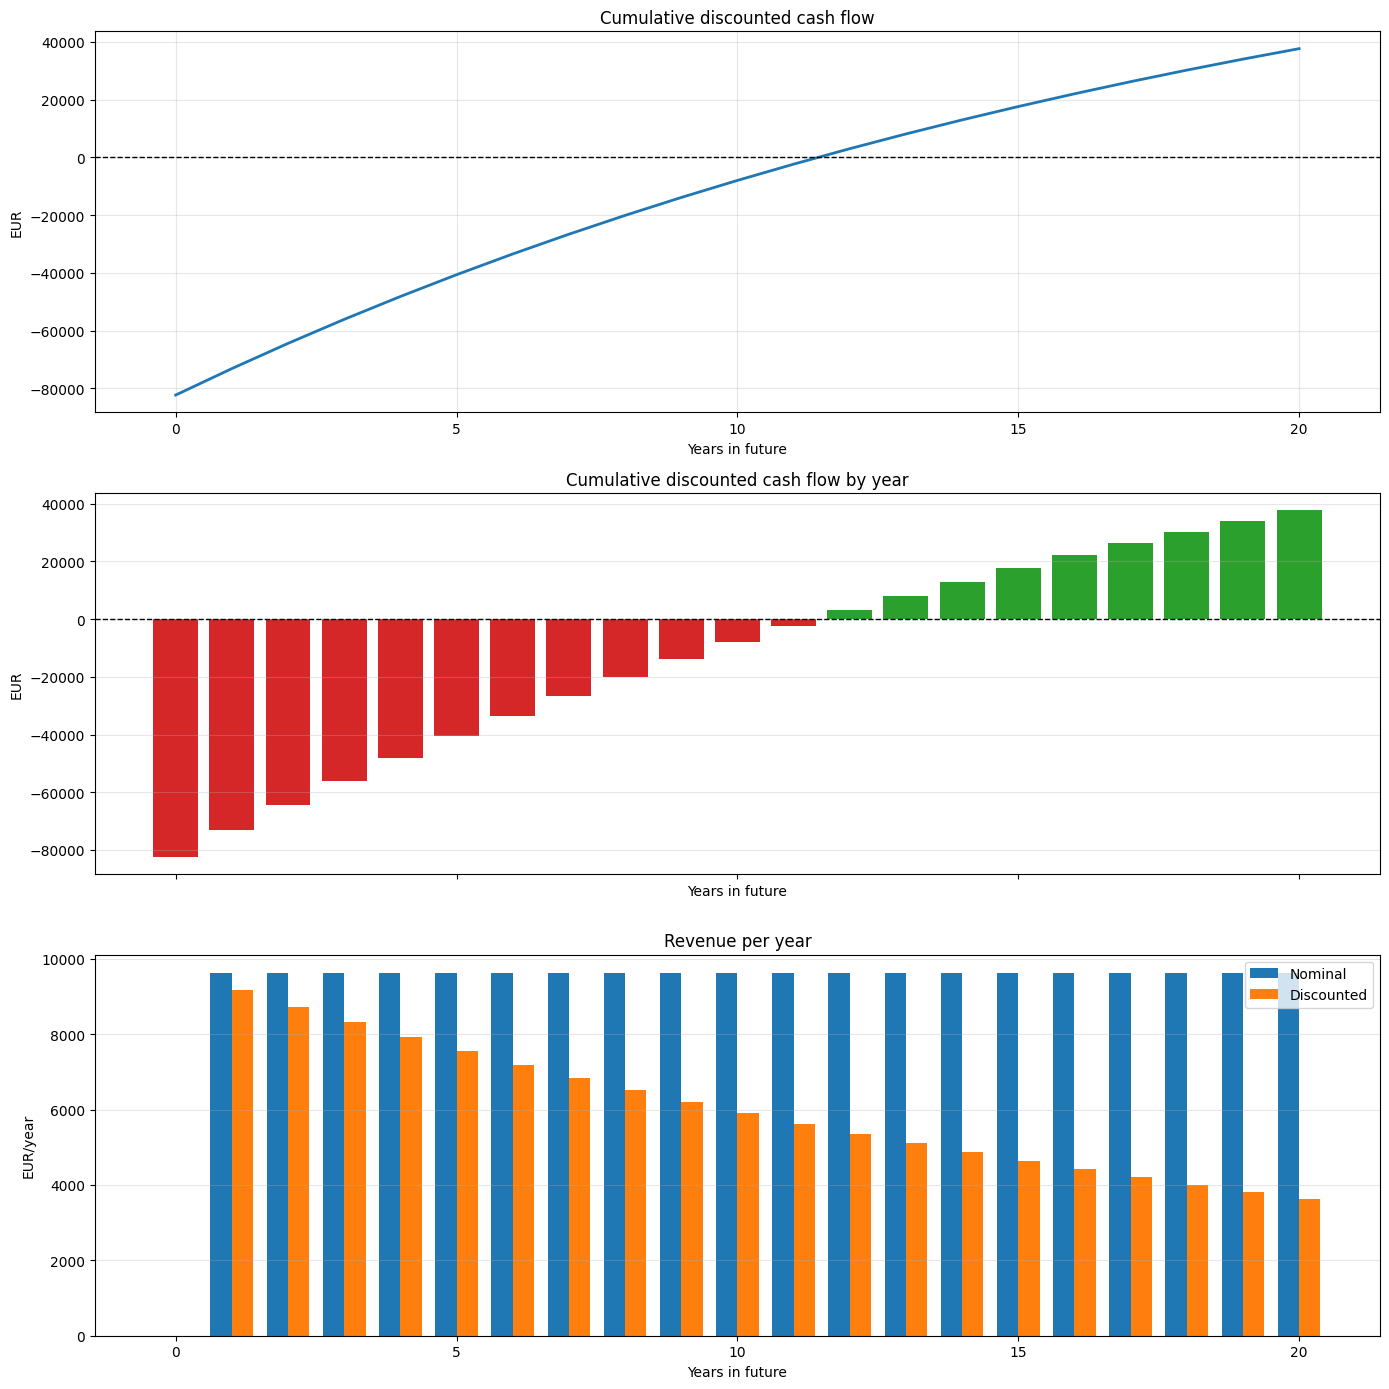

In [50]:
# --- future cumulative cash flow projection ---
projection_year = 2025
projection_horizon_years = 20
projection_average_spread = None

projection_revenue_df, _ = calculate_daily_revenue(
    df,
    power=power,
    max_daily_cycles=2,
    round_trip_efficiency=round_trip_efficiency,
    year=projection_year,
    average_spread=projection_average_spread,
)

annual_revenue_eur = projection_revenue_df["daily_revenue_eur"].sum()
projection_years = np.arange(0, projection_horizon_years + 1)
discounted_cash_flows = np.zeros_like(projection_years, dtype=float)
discounted_cash_flows[1:] = annual_revenue_eur / (1 + Interest_rate) ** projection_years[1:]
cumulative_discounted_cash_flow = -cost + np.cumsum(discounted_cash_flows)

cash_flow_projection_df = pd.DataFrame({
    "Years in future": projection_years,
    "Cumulative discounted cash flow (EUR)": cumulative_discounted_cash_flow,
})

print(f"Projection year repeated: {projection_year}")
print(f"Annual revenue used: {annual_revenue_eur:,.2f} EUR/year")
print(f"Investment cost: {cost:,.2f} EUR")
print(f"Discount rate: {Interest_rate:.2%}")

annual_revenue_projection = np.zeros_like(projection_years, dtype=float)
annual_revenue_projection[1:] = annual_revenue_eur
discounted_revenue_projection = discounted_cash_flows.copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

axes[0].plot(
    cash_flow_projection_df["Years in future"],
    cash_flow_projection_df["Cumulative discounted cash flow (EUR)"],
    color="tab:blue",
    linewidth=2,
)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Cumulative discounted cash flow")
axes[0].set_xlabel("Years in future")
axes[0].set_ylabel("EUR")
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis="x", labelbottom=True)

bar_colors = ["tab:red" if value < 0 else "tab:green" for value in cash_flow_projection_df["Cumulative discounted cash flow (EUR)"]]
axes[1].bar(
    cash_flow_projection_df["Years in future"],
    cash_flow_projection_df["Cumulative discounted cash flow (EUR)"],
    color=bar_colors,
    width=0.8,
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Cumulative discounted cash flow by year")
axes[1].set_xlabel("Years in future")
axes[1].set_ylabel("EUR")
axes[1].grid(True, axis="y", alpha=0.3)

bar_width = 0.38
axes[2].bar(
    projection_years - bar_width / 2,
    annual_revenue_projection,
    color="tab:blue",
    width=bar_width,
    label="Nominal",
)
axes[2].bar(
    projection_years + bar_width / 2,
    discounted_revenue_projection,
    color="tab:orange",
    width=bar_width,
    label="Discounted",
)
axes[2].set_title("Revenue per year")
axes[2].set_xlabel("Years in future")
axes[2].set_ylabel("EUR/year")
axes[2].grid(True, axis="y", alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

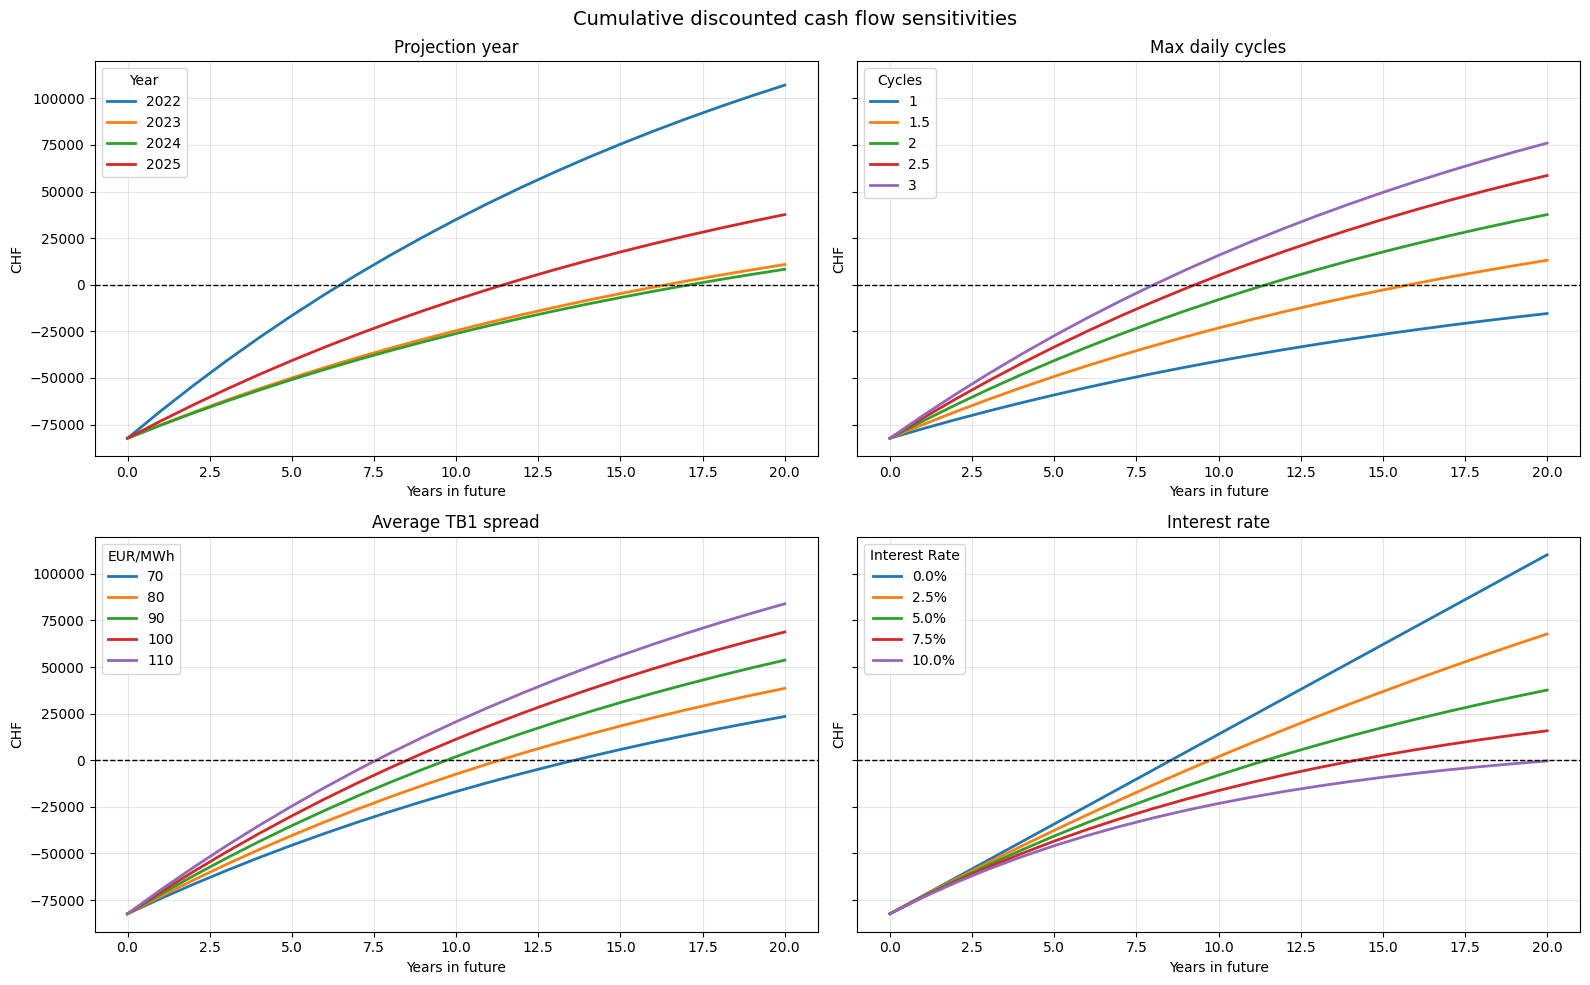

In [51]:
# --- sensitivity plots for cumulative discounted cash flow ---
default_projection_year = 2025
default_max_daily_cycles = 2
default_average_spread = None
default_interest_rate = 0.05
projection_horizon_years = 20

def build_cash_flow_curve(projection_year, max_daily_cycles, average_spread, interest_rate):
    revenue_df, _ = calculate_daily_revenue(
        df,
        power=power,
        max_daily_cycles=max_daily_cycles,
        round_trip_efficiency=round_trip_efficiency,
        year=projection_year,
        average_spread=average_spread,
    )
    annual_revenue_eur = revenue_df["daily_revenue_eur"].sum()
    years = np.arange(0, projection_horizon_years + 1)
    discounted_cash_flows = np.zeros_like(years, dtype=float)
    discounted_cash_flows[1:] = annual_revenue_eur / (1 + interest_rate) ** years[1:]
    cumulative_discounted_cash_flow = -cost + np.cumsum(discounted_cash_flows)
    return years, cumulative_discounted_cash_flow

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()

# Plot 1: projection year
for projection_year in [2022, 2023, 2024, 2025]:
    years, curve = build_cash_flow_curve(
        projection_year=projection_year,
        max_daily_cycles=default_max_daily_cycles,
        average_spread=default_average_spread,
        interest_rate=default_interest_rate,
    )
    axes[0].plot(years, curve, label=str(projection_year), linewidth=2)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Projection year")
axes[0].set_xlabel("Years in future")
axes[0].set_ylabel("CHF")
axes[0].tick_params(axis="x", labelbottom=True)
axes[0].legend(title="Year")
axes[0].grid(True, alpha=0.3)

# Plot 2: max daily cycles
for max_daily_cycles_scenario in [1, 1.5, 2, 2.5, 3]:
    years, curve = build_cash_flow_curve(
        projection_year=default_projection_year,
        max_daily_cycles=max_daily_cycles_scenario,
        average_spread=default_average_spread,
        interest_rate=default_interest_rate,
    )
    axes[1].plot(years, curve, label=str(max_daily_cycles_scenario), linewidth=2)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Max daily cycles")
axes[1].set_xlabel("Years in future")
axes[1].set_ylabel("CHF")
axes[1].tick_params(axis="x", labelbottom=True)
axes[1].legend(title="Cycles")
axes[1].grid(True, alpha=0.3)

# Plot 3: average spread
for average_spread_scenario in [70, 80, 90, 100, 110]:
    years, curve = build_cash_flow_curve(
        projection_year=default_projection_year,
        max_daily_cycles=default_max_daily_cycles,
        average_spread=average_spread_scenario,
        interest_rate=default_interest_rate,
    )
    axes[2].plot(years, curve, label=str(average_spread_scenario), linewidth=2)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Average TB1 spread")
axes[2].set_xlabel("Years in future")
axes[2].set_ylabel("CHF")
axes[2].legend(title="EUR/MWh")
axes[2].grid(True, alpha=0.3)

# Plot 4: interest rate
for interest_rate_scenario in [0, 0.025, 0.05, 0.075, 0.1]:
    years, curve = build_cash_flow_curve(
        projection_year=default_projection_year,
        max_daily_cycles=default_max_daily_cycles,
        average_spread=default_average_spread,
        interest_rate=interest_rate_scenario,
    )
    axes[3].plot(years, curve, label=f"{interest_rate_scenario:.1%}", linewidth=2)
axes[3].axhline(0, color="black", linestyle="--", linewidth=1)
axes[3].set_title("Interest rate")
axes[3].set_xlabel("Years in future")
axes[3].set_ylabel("CHF")
axes[3].legend(title="Interest Rate")
axes[3].grid(True, alpha=0.3)

fig.suptitle("Cumulative discounted cash flow sensitivities", fontsize=14)
plt.tight_layout()
plt.show()

In [52]:
# --- properly constrained hourly SOC optimization for 2025 ---
# We'll use hourly prices from the auction CSV with Hour 1..Hour 24 columns.
price_files = sorted(Path('auction_spot_prices').glob('auction_spot_prices_switzerland_2025.csv'))
if not price_files:
    raise FileNotFoundError('No 2025 spot price file found in auction_spot_prices.')
hourly_prices = pd.DataFrame()
for f in price_files:
    tmp = pd.read_csv(f, comment='#', dayfirst=True, parse_dates=['Delivery day'], keep_default_na=False)
    if 'Hour 1' not in tmp.columns:
        tmp = pd.read_csv(f, comment='#', skiprows=1, dayfirst=True, parse_dates=['Delivery day'], keep_default_na=False)
    hour_cols = [c for c in tmp.columns if c.strip().startswith('Hour')]
    if not hour_cols:
        raise ValueError(f'No Hour columns found in {f}')
    tmp = tmp[['Delivery day'] + hour_cols].copy()
    hourly_long = tmp.melt(id_vars=['Delivery day'], value_vars=hour_cols, var_name='hour', value_name='price').dropna(subset=['price']).copy()
    hourly_long['hour'] = hourly_long['hour'].str.extract(r'Hour\s*(\d+)').astype(float)
    hourly_long['timestamp'] = hourly_long['Delivery day'] + pd.to_timedelta(hourly_long['hour'] - 1, unit='h')
    hourly_prices = pd.concat([hourly_prices, hourly_long[['timestamp','price']]], ignore_index=True)
hourly_prices = hourly_prices.sort_values('timestamp').reset_index(drop=True)
hourly_prices['price'] = pd.to_numeric(hourly_prices['price'], errors='coerce')
hourly_prices = hourly_prices.dropna(subset=['price']).reset_index(drop=True)
if hourly_prices.empty:
    raise ValueError('No hourly price rows loaded.')
hourly_prices = hourly_prices[hourly_prices['timestamp'].dt.year == 2025].reset_index(drop=True)
if hourly_prices.empty:
    raise ValueError('No 2025 hourly prices after filtering.')
n = len(hourly_prices)
eff_charge = np.sqrt(round_trip_efficiency)
eff_discharge = np.sqrt(round_trip_efficiency)
soc = cp.Variable(n+1)
charge = cp.Variable(n)
discharge = cp.Variable(n)
max_power = power
constraints = [soc[0] == 0, soc >= 0, soc <= capacity, charge >= 0, discharge >= 0, charge <= max_power, discharge <= max_power, charge + discharge <= max_power]
for t in range(n):
    constraints.append(soc[t+1] == soc[t] + eff_charge * charge[t] - discharge[t] / eff_discharge)
hourly_prices['day'] = hourly_prices['timestamp'].dt.floor('D')
for day, idxs in hourly_prices.groupby('day').groups.items():
    constraints.append(cp.sum(discharge[list(idxs)]) <= max_daily_cycles * capacity)
price_vec = hourly_prices['price'].to_numpy(dtype=float)
objective = cp.Maximize(price_vec @ (discharge - charge))
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS, verbose=False, max_iters=100000)
print('Optimization status:', prob.status)
if prob.status not in ['optimal','optimal_inaccurate']:
    raise RuntimeError('Solver did not find optimal solution')
opt_revenue = float(prob.value)
print(f'Max SOC-constrained arbitrage revenue in 2025: {opt_revenue:,.2f} EUR')
hourly_prices['charge_mw'] = charge.value
hourly_prices['discharge_mw'] = discharge.value
hourly_prices['soc_mwh'] = soc.value[1:]
print(hourly_prices[['timestamp','price','charge_mw','discharge_mw','soc_mwh']].head(10))


Optimization status: optimal
Max SOC-constrained arbitrage revenue in 2025: 5,174.02 EUR
            timestamp   price     charge_mw  discharge_mw       soc_mwh
0 2025-01-01 00:00:00  102.20  5.663584e-11  2.577420e-11  2.514651e-11
1 2025-01-01 01:00:00   98.20  5.314957e-11  2.743283e-11  4.573144e-11
2 2025-01-01 02:00:00   72.60 -3.505909e-11  1.074067e-10 -1.015880e-10
3 2025-01-01 03:00:00   67.85  1.162990e-02  2.826547e-10  1.103309e-02
4 2025-01-01 04:00:00   62.87  1.075000e-01  3.363161e-10  1.130165e-01
5 2025-01-01 05:00:00   58.99  1.075000e-01  4.070604e-10  2.150000e-01
6 2025-01-01 06:00:00   68.57 -6.107402e-11  1.328479e-10  2.150000e-01
7 2025-01-01 07:00:00   74.03  1.682101e-11  5.337138e-11  2.150000e-01
8 2025-01-01 08:00:00   76.55  4.162050e-11  2.843954e-11  2.150000e-01
9 2025-01-01 09:00:00   88.10  9.753780e-11  1.075000e-01  1.016851e-01


In [53]:
# --- Optimization with consumption headroom from 200pv_500ev ---
pv_ev = pd.read_excel(Path('PV+consumption_data/200pv_500ev.xlsx'))
col_strings = [str(c) for c in pv_ev.columns]
def col_score(c):
    lc = str(c).lower()
    if 'battery' in lc and 'power' in lc: return 3
    if 'power' in lc and ('kw' in lc or 'mw' in lc): return 2
    if 'power' in lc: return 1
    return 0
scored = sorted([(col_score(c), c) for c in col_strings], key=lambda x: (-x[0], str(x[1])))
candidate_cols = [c for score, c in scored if score > 0]
if not candidate_cols:
    numeric_cols = pv_ev.select_dtypes(include='number').columns.tolist()
    if not numeric_cols:
        raise ValueError('Cannot detect battery power column automatically. Please inspect columns.')
    candidate_cols = numeric_cols
flow_col = candidate_cols[0]
print('Using flow column:', flow_col)
pv_ev['own_flow_kw'] = pd.to_numeric(pv_ev[flow_col], errors='coerce')
if 'mw' in str(flow_col).lower():
    pv_ev['own_flow_mw'] = pv_ev['own_flow_kw']
else:
    pv_ev['own_flow_mw'] = pv_ev['own_flow_kw'] / 1000.0
max_battery_power_mw = power
pv_ev['arbitrage_headroom_mw'] = np.maximum(0, max_battery_power_mw - pv_ev['own_flow_mw'].abs())
print('Mean headroom (MW):', pv_ev['arbitrage_headroom_mw'].mean())
# Determine timestamp column for PV file
col_lower = {str(c).lower(): c for c in pv_ev.columns}
ts_col = None
if 'timestamp' in col_lower:
    ts_col = col_lower['timestamp']
elif 'datetime' in col_lower:
    ts_col = col_lower['datetime']
elif 'date' in col_lower:
    ts_col = col_lower['date']
else:
    dt_cols = [c for c in pv_ev.columns if pd.api.types.is_datetime64_any_dtype(pv_ev[c])]
    if dt_cols:
        ts_col = dt_cols[0]
if ts_col is None:
    raise ValueError('No timestamp-like column found in PV file.')
pv_ev[ts_col] = pd.to_datetime(pv_ev[ts_col], errors='coerce')
pv_ev = pv_ev.sort_values(ts_col).reset_index(drop=True)
pv_ev = pv_ev.dropna(subset=[ts_col,'own_flow_mw'])
# Build hourly optimization from previous hourly pricing data if available
if 'hourly_prices' not in globals():
    # rebuild hourly_prices same as pre-optimization cell
    f = list(Path('auction_spot_prices').glob('auction_spot_prices_switzerland_2025.csv'))
    if not f:
        raise FileNotFoundError('No 2025 auction file found for optimization.')
    tmp = pd.read_csv(f[0], comment='#', dayfirst=True, parse_dates=['Delivery day'], keep_default_na=False)
    if 'Hour 1' not in tmp.columns:
        tmp = pd.read_csv(f[0], comment='#', skiprows=1, dayfirst=True, parse_dates=['Delivery day'], keep_default_na=False)
    hour_cols = [c for c in tmp.columns if c.strip().startswith('Hour')]
    tmp = tmp[['Delivery day'] + hour_cols].copy()
    hourly_long = tmp.melt(id_vars=['Delivery day'], value_vars=hour_cols, var_name='hour', value_name='price').dropna(subset=['price']).copy()
    hourly_long['hour'] = hourly_long['hour'].str.extract(r'Hour\s*(\d+)').astype(float)
    hourly_long['timestamp'] = hourly_long['Delivery day'] + pd.to_timedelta(hourly_long['hour'] - 1, unit='h')
    hourly_prices = hourly_long[['timestamp','price']].sort_values('timestamp').reset_index(drop=True)
hourly_prices['price'] = pd.to_numeric(hourly_prices['price'], errors='coerce')
hourly_prices = hourly_prices.dropna(subset=['price']).reset_index(drop=True)
hourly_prices = hourly_prices[hourly_prices['timestamp'].dt.year == 2025].reset_index(drop=True)
if hourly_prices.empty:
    raise ValueError('No 2025 hourly prices available for optimization')
# align timestamps to nearest hour for headroom
pv_ev['timestamp'] = pd.to_datetime(pv_ev[ts_col]).dt.floor('h')
hourly_prices = hourly_prices.rename(columns={'timestamp':'timestamp'})
hourly_prices = hourly_prices.merge(pv_ev[['timestamp','arbitrage_headroom_mw']], on='timestamp', how='left')
hourly_prices['arbitrage_headroom_mw'] = hourly_prices['arbitrage_headroom_mw'].fillna(max_battery_power_mw)
hourly_prices['headroom_mw'] = np.minimum(max_battery_power_mw, hourly_prices['arbitrage_headroom_mw'])
n = len(hourly_prices)
eff_charge = np.sqrt(round_trip_efficiency)
eff_discharge = np.sqrt(round_trip_efficiency)
soc = cp.Variable(n+1)
charge = cp.Variable(n)
discharge = cp.Variable(n)
headroom_param = cp.Parameter(n, nonneg=True)
headroom_param.value = hourly_prices['headroom_mw'].to_numpy(dtype=float)
constraints = [soc[0]==0, soc>=0, soc<=capacity, charge>=0, discharge>=0, charge<=headroom_param, discharge<=headroom_param, charge+discharge<=headroom_param]
for t in range(n):
    constraints.append(soc[t+1] == soc[t] + eff_charge*charge[t] - discharge[t]/eff_discharge)
for day, idxs in hourly_prices.groupby(hourly_prices['timestamp'].dt.floor('D')).groups.items():
    constraints.append(cp.sum(discharge[list(idxs)]) <= max_daily_cycles * capacity)
price_vec = hourly_prices['price'].to_numpy(dtype=float)
objective = cp.Maximize(price_vec @ (discharge - charge))
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS, verbose=False, max_iters=200000)
print('Optimization status with headroom:', prob.status)
if prob.status not in ['optimal','optimal_inaccurate']:
    raise RuntimeError('Solver did not find optimal solution for headroom-constrained optimization')
opt_revenue_with_headroom = float(prob.value)
print(f'Max arbitrage revenue in 2025 with headroom constraints: {opt_revenue_with_headroom:,.2f} EUR')
hourly_prices['charge_mw'] = charge.value
hourly_prices['discharge_mw'] = discharge.value
hourly_prices['soc_mwh'] = soc.value[1:]
print(hourly_prices[['timestamp','price','headroom_mw','charge_mw','discharge_mw','soc_mwh']].head(10))


Using flow column: 0
Mean headroom (MW): 0.1040439192208684
Optimization status with headroom: optimal
Max arbitrage revenue in 2025 with headroom constraints: 5,135.96 EUR
            timestamp   price  headroom_mw     charge_mw  discharge_mw  \
0 2025-01-01 00:00:00  102.20       0.1075 -1.032643e-09 -2.472817e-10   
1 2025-01-01 01:00:00   98.20       0.1075 -1.162999e-09 -6.615462e-11   
2 2025-01-01 02:00:00   72.60       0.1075 -9.977866e-12 -1.001256e-09   
3 2025-01-01 03:00:00   67.85       0.1075  1.162989e-02 -9.325973e-10   
4 2025-01-01 04:00:00   62.87       0.1075  1.075000e-01 -1.294961e-09   
5 2025-01-01 05:00:00   58.99       0.1075  1.075000e-01 -1.685322e-09   
6 2025-01-01 06:00:00   68.57       0.1075 -2.311637e-10 -7.241864e-10   
7 2025-01-01 07:00:00   74.03       0.1075 -5.183793e-10 -4.811729e-10   
8 2025-01-01 08:00:00   76.55       0.1075 -4.704973e-10 -5.591768e-10   
9 2025-01-01 09:00:00   88.10       0.1075 -8.901892e-10  1.075000e-01   

        soc_

Total 2025 revenue without headroom: 5,174.02 EUR
Total 2025 revenue with headroom: 5,135.95 EUR


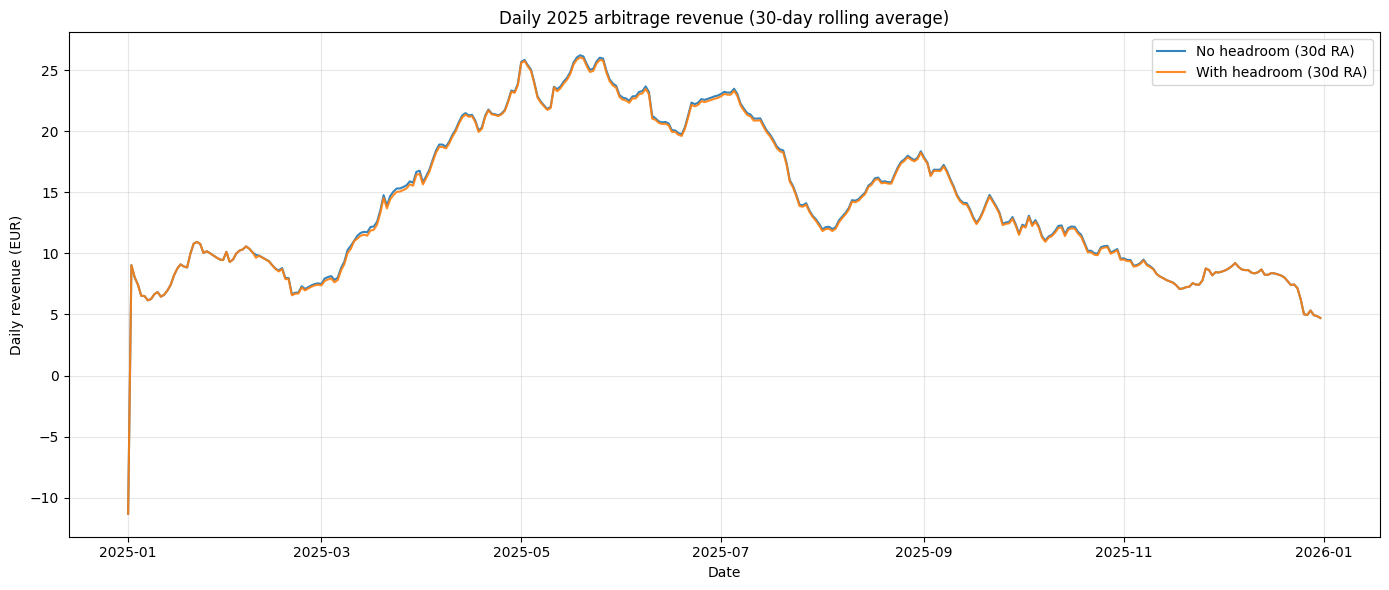

In [54]:
# --- Final comparison: daily revenue 2025 with and without headroom ---
# Build hourly prices for 2025
price_file = list(Path('auction_spot_prices').glob('auction_spot_prices_switzerland_2025.csv'))[0]
tmp = pd.read_csv(price_file, comment='#', dayfirst=True, parse_dates=['Delivery day'], keep_default_na=False)
if 'Hour 1' not in tmp.columns:
    tmp = pd.read_csv(price_file, comment='#', skiprows=1, dayfirst=True, parse_dates=['Delivery day'], keep_default_na=False)
hour_cols = [c for c in tmp.columns if str(c).strip().startswith('Hour')]
hourly_long = tmp.melt(id_vars=['Delivery day'], value_vars=hour_cols, var_name='hour', value_name='price').dropna(subset=['price']).copy()
hourly_long['hour'] = hourly_long['hour'].str.extract(r'Hour\s*(\d+)').astype(float)
hourly_long['timestamp'] = hourly_long['Delivery day'] + pd.to_timedelta(hourly_long['hour'] - 1, unit='h')
prices_2025 = hourly_long[['timestamp','price']].sort_values('timestamp').reset_index(drop=True)
prices_2025['price'] = pd.to_numeric(prices_2025['price'], errors='coerce')
prices_2025 = prices_2025.dropna(subset=['price']).reset_index(drop=True)
prices_2025 = prices_2025[prices_2025['timestamp'].dt.year == 2025].reset_index(drop=True)
# headroom from PV+EV
pv_ev = pd.read_excel(Path('PV+consumption_data/200pv_500ev.xlsx'))
flow_col = None
for c in pv_ev.columns:
    lc = str(c).lower()
    if 'battery' in lc and 'power' in lc:
        flow_col = c
        break
if flow_col is None:
    for c in pv_ev.columns:
        lc = str(c).lower()
        if 'power' in lc:
            flow_col = c
            break
if flow_col is None:
    numeric = pv_ev.select_dtypes(include='number').columns
    if len(numeric)==0:
        raise ValueError('Cannot find flow column in PV file')
    flow_col = numeric[0]
pv_ev['own_flow_kw'] = pd.to_numeric(pv_ev[flow_col], errors='coerce')
pv_ev['own_flow_mw'] = pv_ev['own_flow_kw'] / 1000.0
# detect ts col
ts_col = None
for c in pv_ev.columns:
    if str(c).lower() in ['timestamp','datetime','date']:
        ts_col = c
        break
if ts_col is None:
    dt_cols = [c for c in pv_ev.columns if pd.api.types.is_datetime64_any_dtype(pv_ev[c])]
    if len(dt_cols):
        ts_col = dt_cols[0]
if ts_col is None:
    raise ValueError('No timestamp-like column in PV file')
pv_ev[ts_col] = pd.to_datetime(pv_ev[ts_col], errors='coerce')
pv_ev = pv_ev.dropna(subset=[ts_col,'own_flow_mw']).copy()
pv_ev['timestamp'] = pd.to_datetime(pv_ev[ts_col]).dt.floor('h')
pv_ev['arbitrage_headroom_mw'] = np.maximum(0, power - pv_ev['own_flow_mw'].abs())
prices_headroom = prices_2025.merge(pv_ev[['timestamp','arbitrage_headroom_mw']], on='timestamp', how='left')
prices_headroom['arbitrage_headroom_mw'] = prices_headroom['arbitrage_headroom_mw'].fillna(power)
prices_headroom['headroom_mw'] = np.minimum(power, prices_headroom['arbitrage_headroom_mw'])
def solve_hourly(prices_df, capacity, power, eta, daily_cycles, headroom=None):
    n = len(prices_df)
    eff_c = np.sqrt(eta)
    eff_d = np.sqrt(eta)
    soc = cp.Variable(n+1)
    charge = cp.Variable(n)
    discharge = cp.Variable(n)
    constraints = [soc[0]==0, soc>=0, soc<=capacity, charge>=0, discharge>=0, charge<=power, discharge<=power]
    if headroom is not None:
        hr_param = cp.Parameter(n, nonneg=True)
        hr_param.value = np.minimum(power, headroom.astype(float))
        constraints += [charge<=hr_param, discharge<=hr_param, charge+discharge<=hr_param]
    for t in range(n):
        constraints.append(soc[t+1] == soc[t] + eff_c*charge[t] - discharge[t]/eff_d)
    for day, idxs in prices_df.groupby(prices_df['timestamp'].dt.floor('D')).groups.items():
        constraints.append(cp.sum(discharge[list(idxs)]) <= daily_cycles * capacity)
    objective = cp.Maximize(prices_df['price'].to_numpy(dtype=float) @ (discharge - charge))
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, verbose=False, max_iters=200000)
    if prob.status not in ['optimal','optimal_inaccurate']:
        raise RuntimeError('Solver did not converge')
    out = prices_df.copy()
    out['charge_mw'] = charge.value
    out['discharge_mw'] = discharge.value
    out['soc_mwh'] = soc.value[1:]
    out['revenue_eur'] = out['price'] * (out['discharge_mw'] - out['charge_mw'])
    daily = out.groupby(out['timestamp'].dt.floor('D'))['revenue_eur'].sum().reset_index(name='daily_revenue_eur')
    return out, daily, float(prob.value)
_, daily_no_headroom, rev_no = solve_hourly(prices_2025, capacity, power, round_trip_efficiency, max_daily_cycles, headroom=None)
_, daily_with_headroom, rev_headroom = solve_hourly(prices_headroom, capacity, power, round_trip_efficiency, max_daily_cycles, headroom=prices_headroom['headroom_mw'].to_numpy(dtype=float))
comparison = daily_no_headroom.rename(columns={'daily_revenue_eur':'revenue_no_headroom'}).merge(daily_with_headroom.rename(columns={'daily_revenue_eur':'revenue_with_headroom'}), on='timestamp', how='outer').sort_values('timestamp').fillna(0)
comparison['roll_no_headroom'] = comparison['revenue_no_headroom'].rolling(window=30, min_periods=1).mean()
comparison['roll_with_headroom'] = comparison['revenue_with_headroom'].rolling(window=30, min_periods=1).mean()
print(f'Total 2025 revenue without headroom: {rev_no:,.2f} EUR')
print(f'Total 2025 revenue with headroom: {rev_headroom:,.2f} EUR')
plt.figure(figsize=(14,6))
plt.plot(comparison['timestamp'], comparison['roll_no_headroom'], label='No headroom (30d RA)', alpha=0.9)
plt.plot(comparison['timestamp'], comparison['roll_with_headroom'], label='With headroom (30d RA)', alpha=0.9)
plt.title('Daily 2025 arbitrage revenue (30-day rolling average)')
plt.xlabel('Date')
plt.ylabel('Daily revenue (EUR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
